# NHANES Depression Risk Prediction  
## Model Development and Evaluation

This notebook develops and evaluates machine-learning models for predicting elevated depressive-symptom risk among eligible NHANES 2017–2018 participants.

Elevated risk is defined as a PHQ-9 score of 10 or higher. PHQ-9 questionnaire items and derived PHQ-9 scores are excluded from the predictors to prevent target leakage.

### Objectives

1. Load and validate the preprocessed modeling dataset.
2. Create a stratified training and test split.
3. Build leakage-safe preprocessing pipelines.
4. Establish a baseline classifier.
5. Train and compare multiple classification models.
6. Address target-class imbalance.
7. Evaluate models using clinically relevant classification metrics.
8. Select and save the final prediction pipeline.

### Evaluation Strategy

Because only 9.06% of participants belong to the elevated-risk class, model performance will not be evaluated using accuracy alone. The primary evaluation measures will include:

- Recall
- Precision
- F1-score
- ROC-AUC
- Precision-recall AUC
- Confusion matrix

The final model is intended for risk screening and educational analysis—not clinical diagnosis.

In [1]:
# Import standard Python utilities
from pathlib import Path
import warnings

# Import data-processing libraries
import numpy as np
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import model-selection utilities
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Import classification models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression

# Import model-evaluation metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Configure notebook display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Apply a consistent visualization style
sns.set_theme(style="whitegrid", context="notebook")

# Suppress noncritical warnings for cleaner output
warnings.filterwarnings("ignore")

# Set a reproducible random seed
RANDOM_STATE = 42

# Define project locations
processed_data_path = Path(
    "../data/processed/nhanes_2017_2018_preprocessed.csv"
)
models_folder = Path("../models")
figures_folder = Path("../reports/figures")

# Create output folders if they do not already exist
models_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Model-development environment configured successfully.")

Model-development environment configured successfully.


## 1. Load and Validate the Modeling Dataset

The preprocessed dataset contains one row per eligible participant, the binary target, and the predictors created during preprocessing.

`SEQN` is retained only as a participant identifier and will not be used as a model predictor.

In [3]:
# Load the preprocessed modeling dataset
model_df = pd.read_csv(processed_data_path)

# Define the participant identifier and the actual target column
identifier_column = "SEQN"
target_column = "elevated_depression_risk"

# Confirm that the required columns exist before continuing
required_columns = [
    identifier_column,
    target_column,
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in model_df.columns
]

if missing_required_columns:
    raise ValueError(
        "Required columns are missing: "
        f"{missing_required_columns}"
    )

# Store participant identifiers separately for result tracking
participant_ids = model_df[identifier_column].copy()

# Separate the predictors from the identifier and target
X = model_df.drop(
    columns=[
        identifier_column,
        target_column,
    ]
).copy()

# Create the binary target vector
y = model_df[target_column].astype(int).copy()

# Define variables that must not be used as model predictors
prohibited_columns = [
    "SEQN",
    "target",
    "elevated_depression_risk",
    "phq9_score",
    "phq9_completed_items",
    "WTMEC2YR",
    "SDMVPSU",
    "SDMVSTRA",
    "DPQ010",
    "DPQ020",
    "DPQ030",
    "DPQ040",
    "DPQ050",
    "DPQ060",
    "DPQ070",
    "DPQ080",
    "DPQ090",
]

# Check for accidental leakage or survey-design variables
remaining_prohibited_columns = [
    column
    for column in prohibited_columns
    if column in X.columns
]

# Create a validation summary
dataset_validation = pd.Series(
    {
        "number_of_rows": len(model_df),
        "number_of_predictors": X.shape[1],
        "missing_target_values": int(y.isna().sum()),
        "duplicate_participant_ids": int(
            participant_ids.duplicated().sum()
        ),
        "negative_cases": int((y == 0).sum()),
        "positive_cases": int((y == 1).sum()),
        "positive_class_percentage": round(
            y.mean() * 100,
            2,
        ),
        "prohibited_predictor_count": len(
            remaining_prohibited_columns
        ),
    },
    name="result",
)

# Display the validation results
display(dataset_validation.to_frame())

# Confirm successful preparation
print("Dataset loaded successfully.")
print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print(
    "Remaining prohibited predictors:",
    remaining_prohibited_columns,
)

,result
number_of_rows,5068.0000
number_of_predictors,29.0000
missing_target_values,0.0000
duplicate_participant_ids,0.0000
negative_cases,4609.0000
positive_cases,459.0000
positive_class_percentage,9.0600
prohibited_predictor_count,0.0000


Dataset loaded successfully.
Predictor matrix shape: (5068, 29)
Target vector shape: (5068,)
Remaining prohibited predictors: []


## 2. Stratified Training and Test Split

The dataset is divided into training and test sets using an 80/20 split.

Stratification preserves the approximately 9% elevated-risk rate in both subsets. The test set will remain untouched during preprocessing, cross-validation, model selection, and hyperparameter tuning.

This separation provides a more reliable estimate of performance on previously unseen participants.

In [5]:
# Split predictors, target values, and participant identifiers together
X_train, X_test, y_train, y_test, id_train, id_test = (
    train_test_split(
        X,
        y,
        participant_ids,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )
)

# Create a function for summarizing each data split
def summarize_split(split_name, target_values):
    """Return class-distribution information for a dataset split."""

    total_records = len(target_values)
    negative_cases = int((target_values == 0).sum())
    positive_cases = int((target_values == 1).sum())

    return {
        "dataset_split": split_name,
        "total_records": total_records,
        "negative_cases": negative_cases,
        "positive_cases": positive_cases,
        "positive_percentage": round(
            positive_cases / total_records * 100,
            2,
        ),
    }


# Summarize the complete, training, and test datasets
split_summary = pd.DataFrame(
    [
        summarize_split("Complete dataset", y),
        summarize_split("Training set", y_train),
        summarize_split("Test set", y_test),
    ]
).set_index("dataset_split")

# Verify that participant identifiers do not overlap
participant_overlap = set(id_train).intersection(set(id_test))

# Confirm that all observations were assigned exactly once
all_records_accounted_for = (
    len(X_train) + len(X_test) == len(X)
)

# Confirm that predictors and targets remain aligned
training_shapes_match = len(X_train) == len(y_train)
test_shapes_match = len(X_test) == len(y_test)

# Display the class distributions
display(split_summary)

# Print validation results
print("Stratified train-test split completed.")
print("Training predictor shape:", X_train.shape)
print("Test predictor shape:", X_test.shape)
print("Participant ID overlap:", len(participant_overlap))
print(
    "All records accounted for:",
    all_records_accounted_for,
)
print(
    "Training predictors and targets aligned:",
    training_shapes_match,
)
print(
    "Test predictors and targets aligned:",
    test_shapes_match,
)

,total_records,negative_cases,positive_cases,positive_percentage
dataset_split,,,,
Complete dataset,5068,4609,459,9.0600
Training set,4054,3687,367,9.0500
Test set,1014,922,92,9.0700


Stratified train-test split completed.
Training predictor shape: (4054, 29)
Test predictor shape: (1014, 29)
Participant ID overlap: 0
All records accounted for: True
Training predictors and targets aligned: True
Test predictors and targets aligned: True


## 3. Leakage-Safe Preprocessing Pipeline

Predictor preprocessing is performed inside a scikit-learn pipeline so that imputation, encoding, and scaling are learned exclusively from the training data during each cross-validation fold.

The preprocessing strategy is:

- **Numeric predictors:** Median imputation followed by standardization.
- **Categorical predictors:** Most-frequent imputation followed by one-hot encoding.
- **Unknown categories:** Categories appearing only in validation, test, or deployment data are ignored safely.

Numeric survey codes representing categories are identified explicitly rather than treated as continuous measurements.

In [7]:
# Identify columns stored as text, categories, or Boolean values
dtype_categorical_columns = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Define numeric survey codes and engineered status variables
# that represent categories rather than continuous measurements
coded_categorical_candidates = [
    "RIAGENDR",                    # Gender
    "RIDRETH3",                    # Race and ethnicity
    "DMDEDUC2",                    # Education level
    "DMDMARTL",                    # Marital status
    "SLQ030",                      # Snoring frequency
    "SLQ040",                      # Snorting or stopping breathing
    "SLQ050",                      # Sleep difficulty
    "SLQ120",                      # Daytime sleepiness
    "smoking_status",              # Smoking-status category
    "alcohol_use_status",          # Alcohol-use category
    "ever_heavy_daily_drinking",   # Heavy-drinking history
]

# Retain only coded categorical columns present in the dataset
coded_categorical_columns = [
    column
    for column in coded_categorical_candidates
    if column in X_train.columns
]

# Identify binary predictors from the training data only
binary_columns = [
    column
    for column in X_train.columns
    if X_train[column].dropna().nunique() <= 2
]

# Combine all categorical-column definitions
categorical_column_set = set(
    dtype_categorical_columns
    + coded_categorical_columns
    + binary_columns
)

# Preserve the original predictor-column order
categorical_columns = [
    column
    for column in X_train.columns
    if column in categorical_column_set
]

# Treat all remaining predictors as numeric
numeric_columns = [
    column
    for column in X_train.columns
    if column not in categorical_column_set
]

# Verify that every predictor belongs to exactly one group
assigned_columns = set(
    numeric_columns + categorical_columns
)

unassigned_columns = [
    column
    for column in X_train.columns
    if column not in assigned_columns
]

overlapping_columns = set(numeric_columns).intersection(
    categorical_columns
)

# Display the assigned feature groups
feature_type_summary = pd.DataFrame(
    {
        "feature_type": [
            "Numeric",
            "Categorical",
            "Unassigned",
            "Overlapping",
        ],
        "number_of_features": [
            len(numeric_columns),
            len(categorical_columns),
            len(unassigned_columns),
            len(overlapping_columns),
        ],
    }
)

display(feature_type_summary)

print("Numeric predictors:")
print(numeric_columns)

print("\nCategorical predictors:")
print(categorical_columns)

print("\nUnassigned predictors:", unassigned_columns)
print("Overlapping predictors:", list(overlapping_columns))

,feature_type,number_of_features
0,Numeric,13
1,Categorical,16
2,Unassigned,0
3,Overlapping,0


Numeric predictors:
['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'sedentary_minutes_per_day', 'cigarettes_per_day', 'alcohol_frequency', 'average_drinks_per_day', 'binge_drinking_frequency', 'binge_drinking_episodes_30d', 'average_sleep_hours', 'weekend_sleep_difference', 'active_domain_count']

Categorical predictors:
['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL', 'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120', 'smoking_status', 'alcohol_use_status', 'ever_heavy_daily_drinking', 'vigorous_work_activity', 'moderate_work_activity', 'walking_or_bicycling', 'vigorous_recreation', 'moderate_recreation']

Unassigned predictors: []
Overlapping predictors: []


In [9]:
# Create the numeric preprocessing pipeline
# Missing numeric values are replaced with the training-set median,
# and numeric features are standardized for scale-sensitive models.
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

# Create the categorical preprocessing pipeline
# Missing categories are replaced with the most frequent training value,
# and categories are converted into one-hot encoded indicators.
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

# Combine the numeric and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_columns,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Confirm that the preprocessing pipeline is ready
print("Preprocessing pipeline created successfully.")
print("Numeric feature count:", len(numeric_columns))
print(
    "Categorical feature count:",
    len(categorical_columns),
)
print(
    "Total predictors assigned:",
    len(numeric_columns) + len(categorical_columns),
)

Preprocessing pipeline created successfully.
Numeric feature count: 13
Categorical feature count: 16
Total predictors assigned: 29


## 4. Baseline Model

A dummy classifier establishes the minimum performance that meaningful models should exceed.

The baseline predicts according to the training-set class distribution. Because approximately 91% of participants are below the elevated-risk threshold, a model can achieve high accuracy while failing to identify any elevated-risk participants.

Five-fold stratified cross-validation is performed using only the training set. The untouched test set is reserved for final model evaluation.

In [10]:
# Create a baseline pipeline using the same preprocessing workflow
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Define stratified five-fold cross-validation
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Define evaluation metrics appropriate for imbalanced classification
scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

# Evaluate the baseline using only the training dataset
baseline_cv_scores = cross_validate(
    estimator=baseline_pipeline,
    X=X_train,
    y=y_train,
    cv=cross_validation,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)

# Summarize the mean and variability across validation folds
baseline_results = pd.DataFrame(
    {
        "metric": list(scoring_metrics.keys()),
        "mean_cv_score": [
            baseline_cv_scores[f"test_{metric}"].mean()
            for metric in scoring_metrics
        ],
        "standard_deviation": [
            baseline_cv_scores[f"test_{metric}"].std()
            for metric in scoring_metrics
        ],
    }
).set_index("metric")

# Display the cross-validation results
display(
    baseline_results.style.format(
        {
            "mean_cv_score": "{:.4f}",
            "standard_deviation": "{:.4f}",
        }
    )
)

print("Baseline cross-validation completed.")
print("Training observations used:", len(X_train))
print("Number of validation folds:", cross_validation.n_splits)
print("Test set used during baseline evaluation: False")

,mean_cv_score,standard_deviation
metric,,
accuracy,0.9095,0.0006
balanced_accuracy,0.5000,0.0000
precision,0.0000,0.0000
recall,0.0000,0.0000
f1,0.0000,0.0000
roc_auc,0.5000,0.0000
pr_auc,0.0905,0.0006


Baseline cross-validation completed.
Training observations used: 4054
Number of validation folds: 5
Test set used during baseline evaluation: False


## 5. Initial Model Comparison

Three classification algorithms are compared:

1. **Logistic Regression:** An interpretable linear model using balanced class weights.
2. **Random Forest:** A nonlinear ensemble model capable of capturing feature interactions.
3. **Gradient Boosting:** A sequential tree-based model that focuses on correcting previous prediction errors.

Logistic regression and random forest use class weighting to reduce bias toward the majority class. All preprocessing remains inside each model pipeline and is fitted separately within every cross-validation fold.

The primary comparison metrics are recall, F1-score, ROC-AUC, and precision-recall AUC. Accuracy is reported but will not determine model selection.

In [11]:
# Define the initial candidate classification models
candidate_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

# Store the complete model pipelines for later use
model_pipelines = {}

# Store cross-validation results for comparison
model_comparison_records = []

# Add the dummy-classifier results as the benchmark
baseline_record = {
    "model": "Dummy Baseline",
}

for metric in scoring_metrics:
    baseline_record[metric] = baseline_results.loc[
        metric,
        "mean_cv_score",
    ]

model_comparison_records.append(baseline_record)

# Evaluate every candidate model using identical CV folds
for model_name, classifier in candidate_models.items():

    # Combine preprocessing and classification in one pipeline
    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    # Save the unfitted pipeline for future tuning
    model_pipelines[model_name] = model_pipeline

    print(f"Evaluating {model_name}...")

    # Perform leakage-safe stratified cross-validation
    cv_scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )

    # Create one result record containing mean CV scores
    model_record = {
        "model": model_name,
    }

    for metric in scoring_metrics:
        model_record[metric] = cv_scores[
            f"test_{metric}"
        ].mean()

    # Store average fitting time for practical comparison
    model_record["fit_time_seconds"] = cv_scores[
        "fit_time"
    ].mean()

    model_comparison_records.append(model_record)

# Convert the collected results into a comparison table
model_comparison_df = pd.DataFrame(
    model_comparison_records
).set_index("model")

# Add an empty fitting-time value for the previously evaluated baseline
model_comparison_df.loc[
    "Dummy Baseline",
    "fit_time_seconds",
] = np.nan

# Sort models by precision-recall AUC
model_comparison_df = model_comparison_df.sort_values(
    by="pr_auc",
    ascending=False,
)

# Display the professionally formatted comparison table
display(
    model_comparison_df.style.format(
        {
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
            "fit_time_seconds": "{:.2f}",
        }
    ).highlight_max(
        subset=[
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ],
        color="#c6efce",
    )
)

print("Initial model comparison completed.")
print("Models evaluated:", len(model_comparison_df))
print("Test set used during model comparison: False")

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,fit_time_seconds
model,,,,,,,,
Logistic Regression,0.7523,0.7401,0.2276,0.7251,0.3462,0.8092,0.3067,0.05
Gradient Boosting,0.9053,0.5222,0.3431,0.0545,0.0930,0.8078,0.2842,0.94
Random Forest,0.9077,0.5113,0.3217,0.0272,0.0501,0.8034,0.2772,1.08
Dummy Baseline,0.9095,0.5000,0.0000,0.0000,0.0000,0.5000,0.0905,nan


Initial model comparison completed.
Models evaluated: 4
Test set used during model comparison: False


## 6. Logistic Regression Hyperparameter Tuning

Logistic regression produced the strongest initial cross-validation performance, particularly for recall, F1-score, ROC-AUC, and precision-recall AUC.

A grid search is used to evaluate different regularization strengths and penalty types. Precision-recall AUC is used as the refitting metric because it is more informative than accuracy for the imbalanced target.

The test set remains untouched during hyperparameter tuning.

In [12]:
# Import the grid-search utility
from sklearn.model_selection import GridSearchCV

# Retrieve the unfitted logistic-regression pipeline
logistic_pipeline = model_pipelines[
    "Logistic Regression"
]

# Define regularization settings to evaluate
logistic_parameter_grid = {
    "classifier__C": [
        0.01,
        0.05,
        0.10,
        0.50,
        1.00,
        5.00,
        10.00,
    ],
    "classifier__penalty": [
        "l1",
        "l2",
    ],
}

# Define the metrics that will be recorded during tuning
tuning_scoring_metrics = {
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

# Configure the grid search
logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_parameter_grid,
    scoring=tuning_scoring_metrics,
    refit="pr_auc",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=True,
    error_score="raise",
)

# Fit all candidate configurations using training data only
logistic_grid_search.fit(
    X_train,
    y_train,
)

# Convert the complete grid-search results into a DataFrame
logistic_tuning_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

# Select the most relevant columns for reporting
logistic_tuning_summary = logistic_tuning_results[
    [
        "rank_test_pr_auc",
        "param_classifier__C",
        "param_classifier__penalty",
        "mean_test_balanced_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "mean_test_pr_auc",
        "mean_train_pr_auc",
        "mean_fit_time",
    ]
].copy()

# Rename columns to improve readability
logistic_tuning_summary = logistic_tuning_summary.rename(
    columns={
        "rank_test_pr_auc": "rank",
        "param_classifier__C": "C",
        "param_classifier__penalty": "penalty",
        "mean_test_balanced_accuracy": "balanced_accuracy",
        "mean_test_precision": "precision",
        "mean_test_recall": "recall",
        "mean_test_f1": "f1",
        "mean_test_roc_auc": "roc_auc",
        "mean_test_pr_auc": "validation_pr_auc",
        "mean_train_pr_auc": "training_pr_auc",
        "mean_fit_time": "fit_time_seconds",
    }
)

# Sort configurations from best to worst PR-AUC
logistic_tuning_summary = (
    logistic_tuning_summary
    .sort_values("rank")
    .reset_index(drop=True)
)

# Display the ten strongest configurations
display(
    logistic_tuning_summary.head(10).style.format(
        {
            "C": "{:.2f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "training_pr_auc": "{:.4f}",
            "fit_time_seconds": "{:.3f}",
        }
    )
)

# Store the refitted best pipeline
best_logistic_pipeline = (
    logistic_grid_search.best_estimator_
)

# Report the selected configuration
print("Logistic-regression tuning completed.")
print(
    "Best parameters:",
    logistic_grid_search.best_params_,
)
print(
    "Best cross-validation PR-AUC:",
    round(logistic_grid_search.best_score_, 4),
)
print("Test set used during tuning: False")

,rank,C,penalty,balanced_accuracy,precision,recall,f1,roc_auc,validation_pr_auc,training_pr_auc,fit_time_seconds
0,1,0.50,l2,0.7399,0.2274,0.7251,0.3460,0.8093,0.3067,0.3289,0.033
1,2,1.00,l2,0.7401,0.2276,0.7251,0.3462,0.8092,0.3067,0.3290,0.041
2,3,5.00,l2,0.7416,0.2285,0.7278,0.3476,0.8089,0.3062,0.3302,0.037
3,4,0.05,l2,0.7408,0.2274,0.7278,0.3463,0.8118,0.3060,0.3280,0.033
4,5,10.00,l2,0.7418,0.2289,0.7278,0.3481,0.8089,0.3060,0.3306,0.039
5,6,0.50,l1,0.7377,0.2256,0.7223,0.3436,0.8099,0.3059,0.3283,0.098
6,7,5.00,l1,0.7387,0.2270,0.7223,0.3452,0.8090,0.3057,0.3292,0.511
7,8,10.00,l1,0.7402,0.2279,0.7250,0.3466,0.8088,0.3054,0.3301,0.726
8,9,0.10,l2,0.7376,0.2255,0.7223,0.3434,0.8106,0.3053,0.3285,0.033
9,10,1.00,l1,0.7386,0.2267,0.7223,0.3450,0.8091,0.3053,0.3285,0.090


Logistic-regression tuning completed.
Best parameters: {'classifier__C': 0.5, 'classifier__penalty': 'l2'}
Best cross-validation PR-AUC: 0.3067
Test set used during tuning: False


## Tuning succeeded. The best configuration is:

C = 0.50

penalty = l2

Validation PR-AUC: 0.3067

Training PR-AUC: 0.3289

The small training–validation gap suggests limited overfitting. Performance changed only slightly because the original Logistic Regression settings were already close to optimal. Next, optimize the decision threshold using out-of-fold training predictions.


## 7. Decision-Threshold Optimization

The default classification threshold is 0.50, but this value is not necessarily optimal for an imbalanced screening problem.

Out-of-fold probabilities are generated using the training data and five-fold cross-validation. Each participant's probability is therefore produced by a model that was not trained on that participant.

Two alternative thresholds are evaluated:

- **Maximum-F1 threshold:** Maximizes the balance between precision and recall.
- **Screening threshold:** Produces at least 75% recall while maximizing F1 among qualifying thresholds.

The test set remains untouched during threshold selection.

In [13]:
# Import threshold-analysis utilities
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_curve,
)

# Generate out-of-fold probabilities using training data only
out_of_fold_probabilities = cross_val_predict(
    estimator=best_logistic_pipeline,
    X=X_train,
    y=y_train,
    cv=cross_validation,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Calculate precision and recall across possible thresholds
precision_values, recall_values, threshold_values = (
    precision_recall_curve(
        y_train,
        out_of_fold_probabilities,
    )
)

# Precision and recall contain one additional endpoint
precision_for_thresholds = precision_values[:-1]
recall_for_thresholds = recall_values[:-1]

# Calculate the F1-score associated with every threshold
f1_values = (
    2
    * precision_for_thresholds
    * recall_for_thresholds
    / (
        precision_for_thresholds
        + recall_for_thresholds
        + 1e-12
    )
)

# Store all threshold-level results
threshold_results = pd.DataFrame(
    {
        "threshold": threshold_values,
        "precision": precision_for_thresholds,
        "recall": recall_for_thresholds,
        "f1": f1_values,
    }
)

# Identify the threshold that produces the highest F1-score
maximum_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

# Retain thresholds satisfying the screening recall requirement
minimum_screening_recall = 0.75

screening_threshold_candidates = threshold_results[
    threshold_results["recall"]
    >= minimum_screening_recall
]

# Select the highest-F1 threshold among screening candidates
screening_threshold_row = (
    screening_threshold_candidates
    .sort_values(
        by="f1",
        ascending=False,
    )
    .iloc[0]
)

# Store the candidate thresholds
candidate_thresholds = {
    "Default threshold": 0.50,
    "Maximum-F1 threshold": float(
        maximum_f1_row["threshold"]
    ),
    "Screening threshold": float(
        screening_threshold_row["threshold"]
    ),
}


# Define a reusable threshold-evaluation function
def evaluate_probability_threshold(
    threshold_name,
    threshold_value,
):
    """Calculate classification metrics at a probability threshold."""

    predictions = (
        out_of_fold_probabilities >= threshold_value
    ).astype(int)

    return {
        "threshold_strategy": threshold_name,
        "threshold": threshold_value,
        "accuracy": accuracy_score(
            y_train,
            predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_train,
            predictions,
        ),
        "precision": precision_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_train,
            predictions,
            zero_division=0,
        ),
    }


# Compare performance across candidate thresholds
threshold_comparison = pd.DataFrame(
    [
        evaluate_probability_threshold(
            threshold_name,
            threshold_value,
        )
        for threshold_name, threshold_value
        in candidate_thresholds.items()
    ]
).set_index("threshold_strategy")

# Display the threshold-comparison results
display(
    threshold_comparison.style.format(
        {
            "threshold": "{:.4f}",
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
        }
    ).highlight_max(
        subset=[
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
        ],
        color="#c6efce",
    )
)

# Confirm that threshold selection did not use the test data
print("Threshold optimization completed.")
print(
    "Out-of-fold ROC-AUC:",
    round(
        roc_auc_score(
            y_train,
            out_of_fold_probabilities,
        ),
        4,
    ),
)
print(
    "Out-of-fold PR-AUC:",
    round(
        average_precision_score(
            y_train,
            out_of_fold_probabilities,
        ),
        4,
    ),
)
print("Test set used during threshold selection: False")

,threshold,accuracy,balanced_accuracy,precision,recall,f1
threshold_strategy,,,,,,
Default threshold,0.5000,0.7521,0.7398,0.2274,0.7248,0.3461
Maximum-F1 threshold,0.6680,0.8345,0.7090,0.2865,0.5559,0.3781
Screening threshold,0.4660,0.7304,0.7401,0.2160,0.7520,0.3356


Threshold optimization completed.
Out-of-fold ROC-AUC: 0.808
Out-of-fold PR-AUC: 0.296
Test set used during threshold selection: False


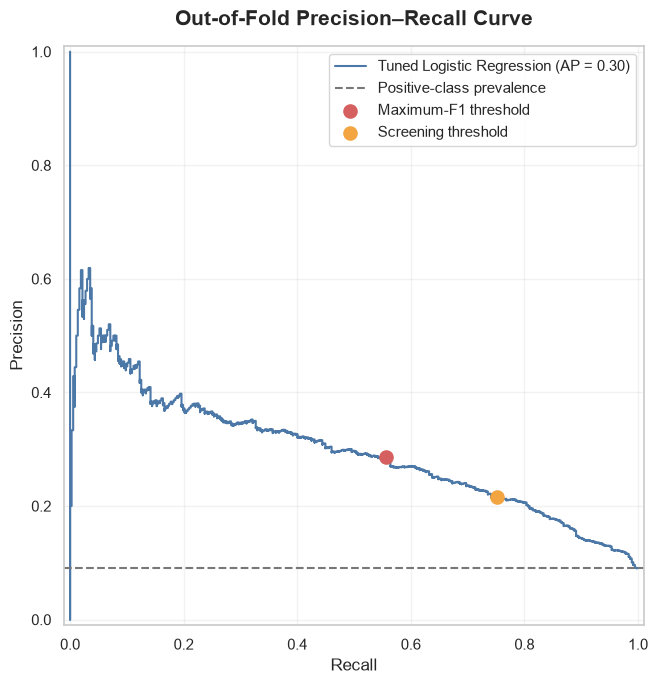

Threshold figure saved.
Saved location: ../reports/figures/logistic_threshold_precision_recall_curve.png


In [14]:
# Create the out-of-fold precision-recall curve
fig, ax = plt.subplots(figsize=(9, 7))

PrecisionRecallDisplay.from_predictions(
    y_train,
    out_of_fold_probabilities,
    name="Tuned Logistic Regression",
    color="#4C78A8",
    ax=ax,
)

# Add the no-skill reference level
ax.axhline(
    y=y_train.mean(),
    color="#777777",
    linestyle="--",
    label="Positive-class prevalence",
)

# Mark the maximum-F1 operating point
ax.scatter(
    maximum_f1_row["recall"],
    maximum_f1_row["precision"],
    color="#D65F5F",
    s=90,
    zorder=5,
    label="Maximum-F1 threshold",
)

# Mark the screening operating point
ax.scatter(
    screening_threshold_row["recall"],
    screening_threshold_row["precision"],
    color="#F2A541",
    s=90,
    zorder=5,
    label="Screening threshold",
)

# Apply professional figure formatting
ax.set_title(
    "Out-of-Fold Precision–Recall Curve",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

plt.tight_layout()

# Save the threshold-analysis figure
threshold_figure_path = (
    figures_folder
    / "logistic_threshold_precision_recall_curve.png"
)

plt.savefig(
    threshold_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Threshold figure saved.")
print("Saved location:", threshold_figure_path)

## 8. Class-Balanced Histogram Gradient Boosting

Histogram Gradient Boosting is evaluated as an additional nonlinear model. Unlike the earlier Gradient Boosting model, this version uses balanced class weights to reduce majority-class bias.

Randomized hyperparameter search is used to explore model complexity, learning rate, regularization, and minimum leaf size efficiently. Precision-recall AUC remains the model-selection metric.

The test set remains untouched.

In [15]:
# Import the class-balanced boosting model and randomized search
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Create a leakage-safe boosting pipeline
histogram_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                class_weight="balanced",
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=20,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Define model settings to explore
histogram_parameter_grid = {
    "classifier__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
    ],
    "classifier__max_iter": [
        100,
        200,
        300,
    ],
    "classifier__max_leaf_nodes": [
        7,
        15,
        31,
    ],
    "classifier__max_depth": [
        None,
        3,
        5,
    ],
    "classifier__min_samples_leaf": [
        10,
        20,
        30,
        50,
    ],
    "classifier__l2_regularization": [
        0.00,
        0.10,
        1.00,
        5.00,
    ],
}

# Configure the randomized hyperparameter search
histogram_random_search = RandomizedSearchCV(
    estimator=histogram_boosting_pipeline,
    param_distributions=histogram_parameter_grid,
    n_iter=25,
    scoring=tuning_scoring_metrics,
    refit="pr_auc",
    cv=cross_validation,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    error_score="raise",
)

# Perform tuning using only the training dataset
histogram_random_search.fit(
    X_train,
    y_train,
)

# Convert search results into a reporting table
histogram_tuning_results = pd.DataFrame(
    histogram_random_search.cv_results_
)

# Select and rename the most useful result columns
histogram_tuning_summary = histogram_tuning_results[
    [
        "rank_test_pr_auc",
        "param_classifier__learning_rate",
        "param_classifier__max_iter",
        "param_classifier__max_leaf_nodes",
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
        "param_classifier__l2_regularization",
        "mean_test_balanced_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "mean_test_pr_auc",
        "mean_train_pr_auc",
    ]
].copy()

histogram_tuning_summary.columns = [
    "rank",
    "learning_rate",
    "max_iterations",
    "max_leaf_nodes",
    "max_depth",
    "minimum_leaf_size",
    "l2_regularization",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "validation_pr_auc",
    "training_pr_auc",
]

# Sort configurations by validation PR-AUC
histogram_tuning_summary = (
    histogram_tuning_summary
    .sort_values("rank")
    .reset_index(drop=True)
)

# Display the ten best configurations
display(
    histogram_tuning_summary.head(10).style.format(
        {
            "learning_rate": "{:.2f}",
            "l2_regularization": "{:.2f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "validation_pr_auc": "{:.4f}",
            "training_pr_auc": "{:.4f}",
        }
    )
)

# Store the best fitted boosting pipeline
best_histogram_pipeline = (
    histogram_random_search.best_estimator_
)

# Compare its PR-AUC with tuned Logistic Regression
performance_improvement = (
    histogram_random_search.best_score_
    - logistic_grid_search.best_score_
)

print("Histogram Gradient Boosting tuning completed.")
print(
    "Best parameters:",
    histogram_random_search.best_params_,
)
print(
    "Best boosting PR-AUC:",
    round(histogram_random_search.best_score_, 4),
)
print(
    "Tuned logistic PR-AUC:",
    round(logistic_grid_search.best_score_, 4),
)
print(
    "PR-AUC difference:",
    round(performance_improvement, 4),
)
print("Test set used during boosting search: False")

,rank,learning_rate,max_iterations,max_leaf_nodes,max_depth,minimum_leaf_size,l2_regularization,balanced_accuracy,precision,recall,f1,roc_auc,validation_pr_auc,training_pr_auc
0,1,0.05,200,31,5,30,5.00,0.7212,0.2434,0.6406,0.3523,0.7985,0.2876,0.6116
1,2,0.03,300,15,5,10,1.00,0.7340,0.2424,0.6788,0.3569,0.8000,0.2875,0.5533
2,3,0.05,100,15,5,20,5.00,0.7284,0.2394,0.6677,0.3522,0.8011,0.2864,0.5609
3,4,0.03,100,31,3,10,5.00,0.7427,0.2384,0.7116,0.3564,0.8065,0.2859,0.4097
4,5,0.10,200,15,5,20,0.00,0.7182,0.2486,0.6241,0.3547,0.7928,0.2823,0.6577
5,6,0.05,300,15,5,50,5.00,0.7206,0.2351,0.6514,0.3449,0.7980,0.2819,0.5518
6,7,0.03,300,15,3,50,1.00,0.7204,0.2296,0.6623,0.3404,0.8034,0.2814,0.4623
7,8,0.08,100,7,3,30,0.00,0.7215,0.2302,0.6650,0.3411,0.8010,0.2806,0.4774
8,9,0.03,300,7,3,30,0.10,0.7229,0.2277,0.6733,0.3394,0.8016,0.2805,0.4516
9,10,0.10,100,7,5,50,1.00,0.7412,0.2372,0.7088,0.3551,0.8073,0.2795,0.4768


Histogram Gradient Boosting tuning completed.
Best parameters: {'classifier__min_samples_leaf': 30, 'classifier__max_leaf_nodes': 31, 'classifier__max_iter': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 5.0}
Best boosting PR-AUC: 0.2876
Tuned logistic PR-AUC: 0.3067
PR-AUC difference: -0.0191
Test set used during boosting search: False


### Histogram Gradient Boosting did not improve performance:

Histogram Boosting PR-AUC: 0.2876

Tuned Logistic Regression PR-AUC: 0.3067

Difference: −0.0191

Therefore, Logistic Regression remains the leading model. This is a valid result—greater model complexity does not automatically produce better generalization.

## 9. Correlated-Feature Sensitivity Analysis

BMI and waist circumference have a Spearman correlation of 0.91. Although regularized logistic regression can tolerate correlated predictors, removing one of these measurements may reduce redundancy and improve generalization.

Four feature configurations are compared using the tuned Logistic Regression model:

1. All 29 predictors
2. BMI removed
3. Waist circumference removed
4. Both body measurements removed

The comparison uses the same training data, cross-validation folds, preprocessing procedures, and evaluation metrics.

In [16]:
# Define alternative predictor configurations
feature_configurations = {
    "All predictors": X_train.columns.tolist(),
    "Without BMI": [
        column
        for column in X_train.columns
        if column != "BMXBMI"
    ],
    "Without waist circumference": [
        column
        for column in X_train.columns
        if column != "BMXWAIST"
    ],
    "Without BMI and waist": [
        column
        for column in X_train.columns
        if column not in ["BMXBMI", "BMXWAIST"]
    ],
}

# Store feature-sensitivity results
feature_sensitivity_records = []

# Evaluate every predictor configuration
for configuration_name, selected_columns in (
    feature_configurations.items()
):

    # Retain numeric variables included in this configuration
    selected_numeric_columns = [
        column
        for column in numeric_columns
        if column in selected_columns
    ]

    # Retain categorical variables included in this configuration
    selected_categorical_columns = [
        column
        for column in categorical_columns
        if column in selected_columns
    ]

    # Create a configuration-specific preprocessor
    configuration_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                selected_numeric_columns,
            ),
            (
                "categorical",
                categorical_pipeline,
                selected_categorical_columns,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    # Use the selected tuned logistic-regression settings
    configuration_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                configuration_preprocessor,
            ),
            (
                "classifier",
                LogisticRegression(
                    C=0.50,
                    penalty="l2",
                    class_weight="balanced",
                    solver="liblinear",
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    # Evaluate the configuration using training data only
    configuration_scores = cross_validate(
        estimator=configuration_pipeline,
        X=X_train[selected_columns],
        y=y_train,
        cv=cross_validation,
        scoring=tuning_scoring_metrics,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )

    # Store mean cross-validation results
    feature_sensitivity_records.append(
        {
            "configuration": configuration_name,
            "predictor_count": len(selected_columns),
            "balanced_accuracy": configuration_scores[
                "test_balanced_accuracy"
            ].mean(),
            "precision": configuration_scores[
                "test_precision"
            ].mean(),
            "recall": configuration_scores[
                "test_recall"
            ].mean(),
            "f1": configuration_scores[
                "test_f1"
            ].mean(),
            "roc_auc": configuration_scores[
                "test_roc_auc"
            ].mean(),
            "pr_auc": configuration_scores[
                "test_pr_auc"
            ].mean(),
        }
    )

# Create and sort the sensitivity-analysis table
feature_sensitivity_df = pd.DataFrame(
    feature_sensitivity_records
).set_index("configuration")

feature_sensitivity_df = feature_sensitivity_df.sort_values(
    by="pr_auc",
    ascending=False,
)

# Display the comparison
display(
    feature_sensitivity_df.style.format(
        {
            "predictor_count": "{:.0f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
        }
    ).highlight_max(
        subset=[
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ],
        color="#c6efce",
    )
)

# Identify the strongest feature configuration
best_feature_configuration = (
    feature_sensitivity_df["pr_auc"].idxmax()
)

print("Correlated-feature analysis completed.")
print(
    "Best feature configuration:",
    best_feature_configuration,
)
print(
    "Best PR-AUC:",
    round(
        feature_sensitivity_df.loc[
            best_feature_configuration,
            "pr_auc",
        ],
        4,
    ),
)
print("Test set used during feature analysis: False")

,predictor_count,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
configuration,,,,,,,
Without BMI and waist,27,0.7409,0.2289,0.7250,0.3477,0.8091,0.3093
Without waist circumference,28,0.7404,0.2283,0.7250,0.3471,0.8087,0.3085
Without BMI,28,0.7392,0.2279,0.7223,0.3462,0.8086,0.3081
All predictors,29,0.7399,0.2274,0.7251,0.3460,0.8093,0.3067


Correlated-feature analysis completed.
Best feature configuration: Without BMI and waist
Best PR-AUC: 0.3093
Test set used during feature analysis: False


This test is quick. If removing BMI or waist increases PR-AUC, we will rebuild the final pipeline with that reduced feature set. If not, we retain all 29 predictors.

## 10. Final Pipeline and Threshold Selection

The correlated-feature sensitivity analysis showed that removing both BMI and waist circumference produced the strongest cross-validation PR-AUC while reducing model complexity.

The final candidate pipeline therefore uses:

- 27 predictors
- Median imputation for numeric variables
- Most-frequent imputation and one-hot encoding for categorical variables
- Standardization of numeric variables
- Balanced Logistic Regression
- L2 regularization with `C = 0.50`

The decision threshold is recalculated using out-of-fold predictions from this reduced model. The test set remains untouched.

In [17]:
# Select the strongest feature configuration
final_selected_columns = feature_configurations[
    "Without BMI and waist"
]

# Create reduced training and test predictor matrices
X_train_final = X_train[
    final_selected_columns
].copy()

X_test_final = X_test[
    final_selected_columns
].copy()

# Identify the remaining numeric predictors
final_numeric_columns = [
    column
    for column in numeric_columns
    if column in final_selected_columns
]

# Identify the remaining categorical predictors
final_categorical_columns = [
    column
    for column in categorical_columns
    if column in final_selected_columns
]

# Build the final preprocessing transformer
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            final_numeric_columns,
        ),
        (
            "categorical",
            categorical_pipeline,
            final_categorical_columns,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Build the final candidate model pipeline
final_model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.50,
                penalty="l2",
                class_weight="balanced",
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Generate leakage-safe out-of-fold probabilities
final_oof_probabilities = cross_val_predict(
    estimator=final_model_pipeline,
    X=X_train_final,
    y=y_train,
    cv=cross_validation,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Calculate precision and recall across possible thresholds
final_precision, final_recall, final_thresholds = (
    precision_recall_curve(
        y_train,
        final_oof_probabilities,
    )
)

# Align precision and recall arrays with the thresholds
final_precision_values = final_precision[:-1]
final_recall_values = final_recall[:-1]

# Calculate F1 at every candidate threshold
final_f1_values = (
    2
    * final_precision_values
    * final_recall_values
    / (
        final_precision_values
        + final_recall_values
        + 1e-12
    )
)

# Create the final threshold-analysis table
final_threshold_results = pd.DataFrame(
    {
        "threshold": final_thresholds,
        "precision": final_precision_values,
        "recall": final_recall_values,
        "f1": final_f1_values,
    }
)

# Identify the maximum-F1 threshold
final_maximum_f1_row = final_threshold_results.loc[
    final_threshold_results["f1"].idxmax()
]

# Identify thresholds providing at least 75% recall
final_screening_candidates = final_threshold_results[
    final_threshold_results["recall"] >= 0.75
]

# Select the highest-F1 screening threshold
final_screening_row = (
    final_screening_candidates
    .sort_values(
        by="f1",
        ascending=False,
    )
    .iloc[0]
)

# Define thresholds to compare
final_candidate_thresholds = {
    "Default threshold": 0.50,
    "Maximum-F1 threshold": float(
        final_maximum_f1_row["threshold"]
    ),
    "Screening threshold": float(
        final_screening_row["threshold"]
    ),
}


# Evaluate one threshold using out-of-fold predictions
def evaluate_final_threshold(
    threshold_name,
    threshold_value,
):
    """Return training OOF metrics for a probability threshold."""

    predictions = (
        final_oof_probabilities >= threshold_value
    ).astype(int)

    return {
        "threshold_strategy": threshold_name,
        "threshold": threshold_value,
        "accuracy": accuracy_score(
            y_train,
            predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_train,
            predictions,
        ),
        "precision": precision_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_train,
            predictions,
            zero_division=0,
        ),
    }


# Compare candidate operating thresholds
final_threshold_comparison = pd.DataFrame(
    [
        evaluate_final_threshold(
            name,
            threshold,
        )
        for name, threshold
        in final_candidate_thresholds.items()
    ]
).set_index("threshold_strategy")

# Display the threshold comparison
display(
    final_threshold_comparison.style.format(
        {
            "threshold": "{:.4f}",
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
        }
    ).highlight_max(
        subset=[
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
        ],
        color="#c6efce",
    )
)

# Select the recall-focused screening threshold
selected_probability_threshold = float(
    final_screening_row["threshold"]
)

# Fit the final pipeline using the complete training dataset
final_model_pipeline.fit(
    X_train_final,
    y_train,
)

# Report the finalized training configuration
print("Final candidate pipeline fitted successfully.")
print("Number of selected predictors:", len(final_selected_columns))
print("Removed predictors: ['BMXBMI', 'BMXWAIST']")
print(
    "Out-of-fold ROC-AUC:",
    round(
        roc_auc_score(
            y_train,
            final_oof_probabilities,
        ),
        4,
    ),
)
print(
    "Out-of-fold PR-AUC:",
    round(
        average_precision_score(
            y_train,
            final_oof_probabilities,
        ),
        4,
    ),
)
print(
    "Selected screening threshold:",
    round(selected_probability_threshold, 4),
)
print("Test set evaluated: False")

,threshold,accuracy,balanced_accuracy,precision,recall,f1
threshold_strategy,,,,,,
Default threshold,0.5000,0.7538,0.7408,0.2287,0.7248,0.3477
Maximum-F1 threshold,0.6730,0.8342,0.7028,0.2831,0.5422,0.3720
Screening threshold,0.4704,0.7306,0.7403,0.2161,0.7520,0.3358


Final candidate pipeline fitted successfully.
Number of selected predictors: 27
Removed predictors: ['BMXBMI', 'BMXWAIST']
Out-of-fold ROC-AUC: 0.8077
Out-of-fold PR-AUC: 0.2986
Selected screening threshold: 0.4704
Test set evaluated: False


### The final candidate is ready:

27 predictors

Tuned balanced Logistic Regression

- Screening threshold: 0.4704

- Training out-of-fold recall: 75.20%

- Training out-of-fold PR-AUC: 0.2986

Now evaluate it once on the untouched test set. We will report both the default and preselected screening thresholds, but we will not adjust the threshold using the test results.

## 11. Final Evaluation on the Untouched Test Set

The finalized pipeline is evaluated once on the held-out test set.

The screening threshold was selected exclusively from out-of-fold training predictions. It is not modified based on test-set performance.

Results are reported at:

- The standard 0.50 threshold
- The preselected screening threshold of approximately 0.47

ROC-AUC and precision-recall AUC evaluate probability ranking and therefore do not change across classification thresholds.

In [18]:
# Generate elevated-risk probabilities for the untouched test set
test_probabilities = final_model_pipeline.predict_proba(
    X_test_final
)[:, 1]

# Define the two thresholds reported in the final evaluation
test_thresholds = {
    "Default threshold": 0.50,
    "Selected screening threshold": (
        selected_probability_threshold
    ),
}


# Calculate final metrics for one threshold
def evaluate_test_threshold(
    threshold_name,
    threshold_value,
):
    """Evaluate test performance at a fixed threshold."""

    test_predictions = (
        test_probabilities >= threshold_value
    ).astype(int)

    # Extract the confusion-matrix components
    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_test,
            test_predictions,
        ).ravel()
    )

    # Calculate specificity for the negative class
    specificity = (
        true_negative
        / (true_negative + false_positive)
    )

    return {
        "threshold_strategy": threshold_name,
        "threshold": threshold_value,
        "accuracy": accuracy_score(
            y_test,
            test_predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            test_predictions,
        ),
        "precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
        "recall_sensitivity": recall_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            test_probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            test_probabilities,
        ),
        "predicted_positive_cases": int(
            test_predictions.sum()
        ),
    }


# Evaluate both predefined thresholds
final_test_results = pd.DataFrame(
    [
        evaluate_test_threshold(
            threshold_name,
            threshold_value,
        )
        for threshold_name, threshold_value
        in test_thresholds.items()
    ]
).set_index("threshold_strategy")

# Display the final test results
display(
    final_test_results.style.format(
        {
            "threshold": "{:.4f}",
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall_sensitivity": "{:.4f}",
            "specificity": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
            "predicted_positive_cases": "{:.0f}",
        }
    )
)

# Create the final predictions using the selected threshold
final_test_predictions = (
    test_probabilities
    >= selected_probability_threshold
).astype(int)

# Display a detailed classification report
final_classification_report = pd.DataFrame(
    classification_report(
        y_test,
        final_test_predictions,
        target_names=[
            "Below threshold",
            "Elevated risk",
        ],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(
    final_classification_report.style.format(
        "{:.4f}"
    )
)

# Display final test-set counts
print("Final test evaluation completed.")
print("Number of test participants:", len(y_test))
print(
    "Actual elevated-risk cases:",
    int(y_test.sum()),
)
print(
    "Predicted elevated-risk cases:",
    int(final_test_predictions.sum()),
)
print(
    "Selected probability threshold:",
    round(selected_probability_threshold, 4),
)
print("Test set evaluated: True")

,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,predicted_positive_cases
threshold_strategy,,,,,,,,,,
Default threshold,0.5000,0.7525,0.7024,0.2130,0.6413,0.7636,0.3198,0.7923,0.2888,277
Selected screening threshold,0.4704,0.7367,0.7084,0.2074,0.6739,0.7430,0.3171,0.7923,0.2888,299


,precision,recall,f1-score,support
Below threshold,0.9580,0.7430,0.8369,922.0000
Elevated risk,0.2074,0.6739,0.3171,92.0000
accuracy,0.7367,0.7367,0.7367,0.7367
macro avg,0.5827,0.7084,0.5770,1014.0000
weighted avg,0.8899,0.7367,0.7897,1014.0000


Final test evaluation completed.
Number of test participants: 1014
Actual elevated-risk cases: 92
Predicted elevated-risk cases: 299
Selected probability threshold: 0.4704
Test set evaluated: True


### Final Test-Set Interpretation

At the preselected screening threshold of 0.4704, the final model achieved:

- **Accuracy:** 73.67%
- **Balanced accuracy:** 70.84%
- **Recall (sensitivity):** 67.39%
- **Specificity:** 74.30%
- **Precision:** 20.74%
- **F1-score:** 0.3171
- **ROC-AUC:** 0.7923
- **Precision-recall AUC:** 0.2888

Of the 92 test participants with elevated depressive-symptom risk, the model correctly identified 62 and missed 30. It also classified 237 below-threshold participants as elevated risk.

The relatively low precision reflects the low prevalence of the positive class and means that model predictions should be used only as an initial screening signal. A positive prediction is not a diagnosis and should require further validated assessment by an appropriate professional.

The test PR-AUC was substantially higher than the positive-class prevalence of approximately 9.07%, demonstrating meaningful predictive value above a no-skill classifier. The ROC-AUC of 0.7923 indicates good, although not perfect, discrimination.

Because the test set has now been evaluated, it will not be used for additional feature selection, threshold adjustment, or hyperparameter tuning.

## 12. Model Interpretation

The final Logistic Regression coefficients are examined to understand how predictors contribute to elevated-risk predictions.

- Positive coefficients increase the model’s predicted elevated-risk probability.
- Negative coefficients decrease the predicted probability.
- Larger absolute coefficients indicate stronger influence within the fitted model.

These coefficients describe model behavior and statistical associations. They do not demonstrate causation or clinical risk.

In [19]:
# Retrieve the fitted preprocessing and classification components
fitted_preprocessor = final_model_pipeline.named_steps[
    "preprocessor"
]

fitted_classifier = final_model_pipeline.named_steps[
    "classifier"
]

# Retrieve feature names after imputation and one-hot encoding
transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

# Retrieve the fitted Logistic Regression coefficients
logistic_coefficients = (
    fitted_classifier.coef_.ravel()
)

# Confirm that feature names and coefficients are aligned
if len(transformed_feature_names) != len(logistic_coefficients):
    raise ValueError(
        "Feature names and coefficients are not aligned."
    )


# Map an encoded feature back to its original variable
def identify_original_feature(transformed_name):
    """Return the original predictor for an encoded feature."""

    # Numeric variables retain their original names
    if transformed_name in final_numeric_columns:
        return transformed_name

    # One-hot features begin with the original variable name
    for column in sorted(
        final_categorical_columns,
        key=len,
        reverse=True,
    ):
        if transformed_name.startswith(f"{column}_"):
            return column

    return transformed_name


# Create the detailed coefficient table
coefficient_df = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "coefficient": logistic_coefficients,
    }
)

# Add coefficient magnitude and direction
coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df["direction"] = np.where(
    coefficient_df["coefficient"] > 0,
    "Higher predicted risk",
    "Lower predicted risk",
)

# Identify each feature's original source variable
coefficient_df["original_feature"] = (
    coefficient_df["transformed_feature"].apply(
        identify_original_feature
    )
)

# Sort transformed features by coefficient magnitude
coefficient_df = coefficient_df.sort_values(
    by="absolute_coefficient",
    ascending=False,
).reset_index(drop=True)

# Display the strongest transformed features
display(
    coefficient_df.head(20).style.format(
        {
            "coefficient": "{:.4f}",
            "absolute_coefficient": "{:.4f}",
        }
    )
)

# Display strongest positive contributors
strongest_positive_coefficients = (
    coefficient_df
    .sort_values(
        by="coefficient",
        ascending=False,
    )
    .head(10)
)

print("Strongest positive model contributions:")
display(
    strongest_positive_coefficients[
        [
            "transformed_feature",
            "original_feature",
            "coefficient",
        ]
    ].style.format(
        {"coefficient": "{:.4f}"}
    )
)

# Display strongest negative contributors
strongest_negative_coefficients = (
    coefficient_df
    .sort_values(
        by="coefficient",
        ascending=True,
    )
    .head(10)
)

print("Strongest negative model contributions:")
display(
    strongest_negative_coefficients[
        [
            "transformed_feature",
            "original_feature",
            "coefficient",
        ]
    ].style.format(
        {"coefficient": "{:.4f}"}
    )
)

,transformed_feature,coefficient,absolute_coefficient,direction,original_feature
0,SLQ120_4.0,0.9474,0.9474,Higher predicted risk,SLQ120
1,SLQ120_0.0,-0.9084,0.9084,Lower predicted risk,SLQ120
2,SLQ050_1.0,0.7681,0.7681,Higher predicted risk,SLQ050
3,SLQ050_2.0,-0.7097,0.7097,Lower predicted risk,SLQ050
4,SLQ120_3.0,0.6772,0.6772,Higher predicted risk,SLQ120
5,DMDMARTL_1.0,-0.6444,0.6444,Lower predicted risk,DMDMARTL
6,SLQ120_1.0,-0.5908,0.5908,Lower predicted risk,SLQ120
7,SLQ040_1.0,0.5042,0.5042,Higher predicted risk,SLQ040
8,DMDMARTL_2.0,0.4949,0.4949,Higher predicted risk,DMDMARTL
9,RIDRETH3_7.0,0.4366,0.4366,Higher predicted risk,RIDRETH3


Strongest positive model contributions:


,transformed_feature,original_feature,coefficient
0,SLQ120_4.0,SLQ120,0.9474
2,SLQ050_1.0,SLQ050,0.7681
4,SLQ120_3.0,SLQ120,0.6772
7,SLQ040_1.0,SLQ040,0.5042
8,DMDMARTL_2.0,DMDMARTL,0.4949
9,RIDRETH3_7.0,RIDRETH3,0.4366
10,DMDEDUC2_1.0,DMDEDUC2,0.3976
11,DMDMARTL_4.0,DMDMARTL,0.3874
13,ever_heavy_daily_drinking_1.0,ever_heavy_daily_drinking,0.3381
15,SLQ030_3.0,SLQ030,0.3120


Strongest negative model contributions:


,transformed_feature,original_feature,coefficient
1,SLQ120_0.0,SLQ120,-0.9084
3,SLQ050_2.0,SLQ050,-0.7097
5,DMDMARTL_1.0,DMDMARTL,-0.6444
6,SLQ120_1.0,SLQ120,-0.5908
12,SLQ040_0.0,SLQ040,-0.3395
14,RIDRETH3_4.0,RIDRETH3,-0.3133
16,ever_heavy_daily_drinking_0.0,ever_heavy_daily_drinking,-0.2796
18,INDFMPIR,INDFMPIR,-0.2634
19,DMDMARTL_6.0,DMDMARTL,-0.2601
20,DMDEDUC2_5.0,DMDEDUC2,-0.2265
